In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd


In [4]:
df=pd.read_csv('urban_traffic_dataset.csv')

In [5]:
df.head()

,timestamp,intersection_id,hour,minute,day_of_week,is_weekend,is_holiday,event_nearby,temperature_c,rain_mm_15min,...,queue_length_veh,incident_flag,prev_count_15min,prev_count_1h,count_same_time_yesterday,count_same_time_last_week,rolling_mean_1h,target_next_count,target_congestion,target_congestion_num
0,2025-01-13 00:00:00,INT_01_CBD,0,0,0,0,0,0,3.5,0.0,...,1.7,0,23.0,31.0,17.0,23.0,26.25,31.0,Low,0
1,2025-01-13 00:15:00,INT_01_CBD,0,15,0,0,0,0,2.7,0.0,...,2.5,0,30.0,21.0,16.0,36.0,26.00,27.0,Low,0
2,2025-01-13 00:30:00,INT_01_CBD,0,30,0,0,0,0,3.1,0.0,...,3.3,0,31.0,30.0,16.0,28.0,28.50,23.0,Low,0
3,2025-01-13 00:45:00,INT_01_CBD,0,45,0,0,0,0,2.5,0.0,...,0.0,0,27.0,23.0,10.0,33.0,27.75,35.0,Low,0
4,2025-01-13 01:00:00,INT_01_CBD,1,0,0,0,0,0,2.2,0.0,...,1.3,0,23.0,30.0,22.0,19.0,27.75,26.0,Low,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 63830 entries, 0 to 63829
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   timestamp                  63830 non-null  str    
 1   intersection_id            63830 non-null  str    
 2   hour                       63830 non-null  int64  
 3   minute                     63830 non-null  int64  
 4   day_of_week                63830 non-null  int64  
 5   is_weekend                 63830 non-null  int64  
 6   is_holiday                 63830 non-null  int64  
 7   event_nearby               63830 non-null  int64  
 8   temperature_c              63830 non-null  float64
 9   rain_mm_15min              63830 non-null  float64
 10  road_capacity_veh_15min    63830 non-null  int64  
 11  vehicle_count              63830 non-null  int64  
 12  avg_speed_kmh              63830 non-null  float64
 13  vehicle_density_per_km     63830 non-null  float64
 14  a

In [7]:
df.isna().sum()

timestamp                    0
intersection_id              0
hour                         0
minute                       0
day_of_week                  0
is_weekend                   0
is_holiday                   0
event_nearby                 0
temperature_c                0
rain_mm_15min                0
road_capacity_veh_15min      0
vehicle_count                0
avg_speed_kmh                0
vehicle_density_per_km       0
avg_waiting_time_sec         0
queue_length_veh             0
incident_flag                0
prev_count_15min             0
prev_count_1h                0
count_same_time_yesterday    0
count_same_time_last_week    0
rolling_mean_1h              0
target_next_count            0
target_congestion            0
target_congestion_num        0
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.isna().sum()

timestamp                    0
intersection_id              0
hour                         0
minute                       0
day_of_week                  0
is_weekend                   0
is_holiday                   0
event_nearby                 0
temperature_c                0
rain_mm_15min                0
road_capacity_veh_15min      0
vehicle_count                0
avg_speed_kmh                0
vehicle_density_per_km       0
avg_waiting_time_sec         0
queue_length_veh             0
incident_flag                0
prev_count_15min             0
prev_count_1h                0
count_same_time_yesterday    0
count_same_time_last_week    0
rolling_mean_1h              0
target_next_count            0
target_congestion            0
target_congestion_num        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

timestamp                        str
intersection_id                  str
hour                           int64
minute                         int64
day_of_week                    int64
is_weekend                     int64
is_holiday                     int64
event_nearby                   int64
temperature_c                float64
rain_mm_15min                float64
road_capacity_veh_15min        int64
vehicle_count                  int64
avg_speed_kmh                float64
vehicle_density_per_km       float64
avg_waiting_time_sec         float64
queue_length_veh             float64
incident_flag                  int64
prev_count_15min             float64
prev_count_1h                float64
count_same_time_yesterday    float64
count_same_time_last_week    float64
rolling_mean_1h              float64
target_next_count            float64
target_congestion                str
target_congestion_num          int64
dtype: object

In [12]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [13]:
df['target_congestion'].unique()

<ArrowStringArray>
['Low', 'Moderate', 'High', 'Severe']
Length: 4, dtype: str

In [14]:
mapping = {'Low': 0, 'Moderate': 1, 'High': 2, 'Severe': 3}
df['target_congestion_num'] = df['target_congestion'].map(mapping)

In [15]:
df.describe()

,timestamp,hour,minute,day_of_week,is_weekend,is_holiday,event_nearby,temperature_c,rain_mm_15min,road_capacity_veh_15min,...,avg_waiting_time_sec,queue_length_veh,incident_flag,prev_count_15min,prev_count_1h,count_same_time_yesterday,count_same_time_last_week,rolling_mean_1h,target_next_count,target_congestion_num
count,63830,63830.000000,63830.000000,63830.000000,63830.000000,63830.000000,63830.000000,63830.000000,63830.000000,63830.000000,...,63830.000000,63830.000000,63830.000000,63830.000000,63830.000000,63830.000000,63830.000000,63830.000000,63830.000000,63830.000000
mean,2025-04-09 11:00:04.145386,11.499499,22.505875,2.970562,0.277393,0.023234,0.003274,17.675656,0.323018,395.020523,...,21.153608,16.433771,0.023046,134.585101,134.542457,134.266975,134.513552,134.565694,134.623923,0.624252
min,2025-01-13 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,260.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,5.250000,1.000000,0.000000
25%,2025-02-25 04:30:00,6.000000,15.000000,1.000000,0.000000,0.000000,0.000000,12.300000,0.000000,260.000000,...,8.600000,1.100000,0.000000,32.000000,32.000000,32.000000,32.000000,32.500000,32.000000,0.000000
50%,2025-04-09 10:37:30,11.000000,15.000000,3.000000,0.000000,0.000000,0.000000,18.500000,0.000000,420.000000,...,14.200000,4.100000,0.000000,85.000000,85.000000,85.000000,85.000000,86.500000,85.000000,0.000000
75%,2025-05-22 15:30:00,17.000000,45.000000,5.000000,1.000000,0.000000,0.000000,23.100000,0.000000,520.000000,...,24.300000,14.300000,0.000000,191.000000,190.000000,190.000000,191.000000,190.750000,191.000000,1.000000
max,2025-07-04 23:30:00,23.000000,45.000000,6.000000,1.000000,1.000000,1.000000,31.500000,12.300000,520.000000,...,118.900000,165.200000,1.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,3.000000
std,NaN,6.921221,16.771691,1.992865,0.447716,0.150646,0.057128,7.110720,1.045038,93.158648,...,20.996369,30.304676,0.150049,135.043008,135.041474,134.696453,135.121858,133.091249,135.047644,0.937804


In [16]:
df.shape

(63830, 25)

In [17]:

(df.select_dtypes(include='number') < 0).sum()

hour                         0
minute                       0
day_of_week                  0
is_weekend                   0
is_holiday                   0
event_nearby                 0
temperature_c                0
rain_mm_15min                0
road_capacity_veh_15min      0
vehicle_count                0
avg_speed_kmh                0
vehicle_density_per_km       0
avg_waiting_time_sec         0
queue_length_veh             0
incident_flag                0
prev_count_15min             0
prev_count_1h                0
count_same_time_yesterday    0
count_same_time_last_week    0
rolling_mean_1h              0
target_next_count            0
target_congestion_num        0
dtype: int64

In [18]:
df.dtypes

timestamp                    datetime64[us]
intersection_id                         str
hour                                  int64
minute                                int64
day_of_week                           int64
is_weekend                            int64
is_holiday                            int64
event_nearby                          int64
temperature_c                       float64
rain_mm_15min                       float64
road_capacity_veh_15min               int64
vehicle_count                         int64
avg_speed_kmh                       float64
vehicle_density_per_km              float64
avg_waiting_time_sec                float64
queue_length_veh                    float64
incident_flag                         int64
prev_count_15min                    float64
prev_count_1h                       float64
count_same_time_yesterday           float64
count_same_time_last_week           float64
rolling_mean_1h                     float64
target_next_count               

In [19]:
df.to_csv('urban_traffic_dataset_cleaned.csv', index=False)

In [20]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


In [21]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

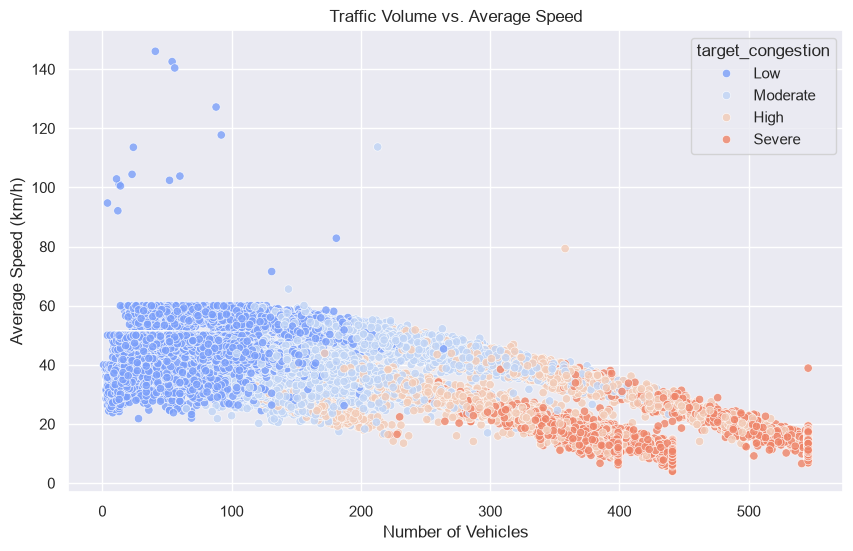

In [23]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='vehicle_count', y='avg_speed_kmh', hue='target_congestion', palette='coolwarm', alpha=0.8)
plt.title('Traffic Volume vs. Average Speed')
plt.xlabel('Number of Vehicles')
plt.ylabel('Average Speed (km/h)')
plt.show()

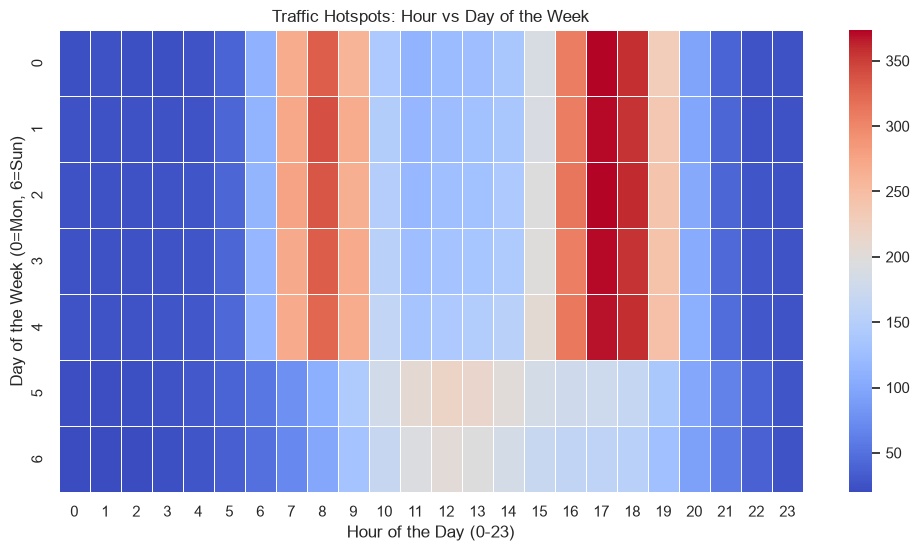

In [31]:
plt.figure(figsize=(12, 6))
pivot_table = df.pivot_table(values='vehicle_count', index='day_of_week', columns='hour', aggfunc='mean')
sns.heatmap(pivot_table, cmap='coolwarm', linewidths=0.5)
plt.title('Traffic Hotspots: Hour vs Day of the Week')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Day of the Week (0=Mon, 6=Sun)')
plt.show()

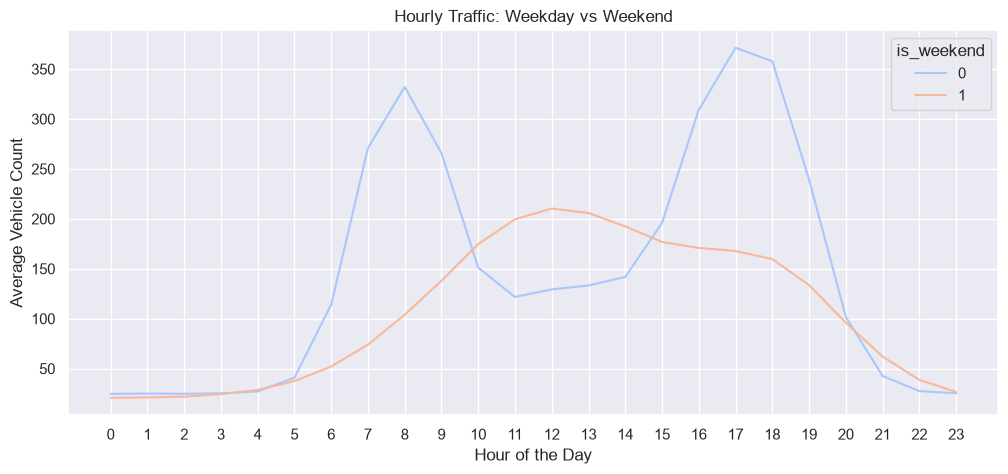

In [32]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='hour', y='vehicle_count', hue='is_weekend', palette='coolwarm', errorbar=None)
plt.title('Hourly Traffic: Weekday vs Weekend')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Vehicle Count')
plt.xticks(range(0, 24))
plt.show()

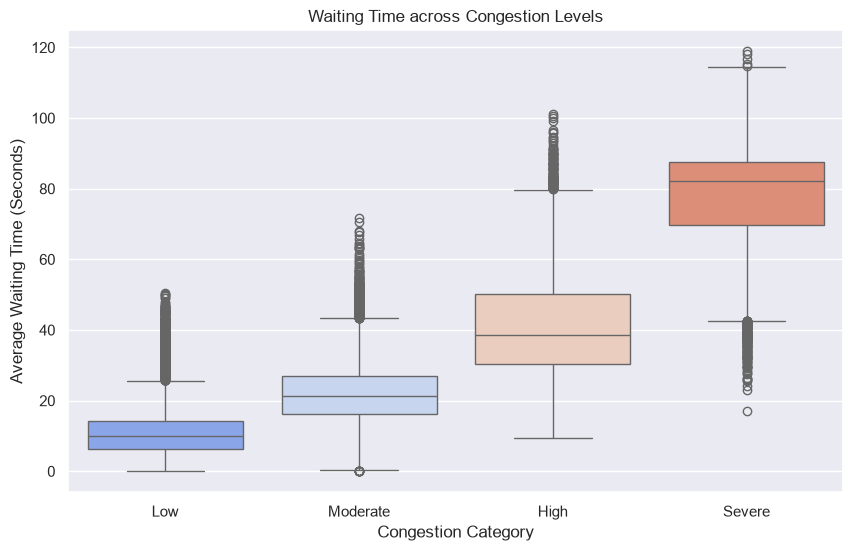

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='target_congestion', y='avg_waiting_time_sec', hue='target_congestion', palette='coolwarm', legend=False)
plt.title('Waiting Time across Congestion Levels')
plt.xlabel('Congestion Category')
plt.ylabel('Average Waiting Time (Seconds)')
plt.show()

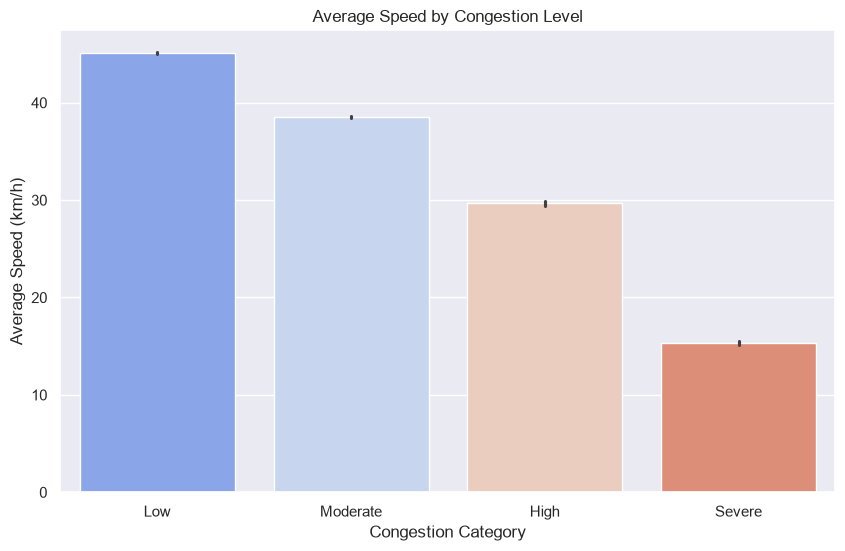

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='target_congestion', y='avg_speed_kmh', hue='target_congestion', palette='coolwarm', legend=False)
plt.title('Average Speed by Congestion Level')
plt.xlabel('Congestion Category')
plt.ylabel('Average Speed (km/h)')
plt.show()